In [1]:
from tabulate import tabulate
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import pandas as pd

# Step 1: Load the data from the CSV file
file_path = 'processed_data.csv'
data = pd.read_csv("processed_data.csv")


# Display the first few rows of the dataset to understand its structure
print(data.head())
print(data.info())
print(data.describe())



   gender   age  hypertension  heart_disease  ever_married  work_type  \
0       1  67.0             0              1             1          0   
1       0  61.0             0              0             1          1   
2       1  80.0             0              1             1          0   
3       0  49.0             0              0             1          0   
4       0  79.0             1              0             1          1   

   Residence_type  avg_glucose_level       bmi  smoking_status  stroke  
0               1             228.69  36.60000               2       1  
1               0             202.21  28.89456               0       1  
2               0             105.92  32.50000               0       1  
3               1             171.23  34.40000               1       1  
4               0             174.12  24.00000               0       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5109 entries, 0 to 5108
Data columns (total 11 columns):
 #   Column     

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
data = pd.read_csv("processed_data.csv")

# Step 2: Split the data into features (X) and target (y)
X = data.drop(columns=['stroke'])  # All columns except the target
y = data['stroke']  # Target column

# Step 3: Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 4: Train the SVM model
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

# Step 5: Evaluate the model
y_pred = svm_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

accuracy, report


c:\Users\Computec\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Computec\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Computec\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av

(0.9510763209393346,
 '              precision    recall  f1-score   support\n\n           0       0.95      1.00      0.97       972\n           1       0.00      0.00      0.00        50\n\n    accuracy                           0.95      1022\n   macro avg       0.48      0.50      0.49      1022\nweighted avg       0.90      0.95      0.93      1022\n')

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
data = pd.read_csv("processed_data.csv")

# Step 2: Split the data into features (X) and target (y)
X = data.drop(columns=['stroke'])  # All columns except the target
y = data['stroke']  # Target column

# Step 3: Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 4: Train the SVM model
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

# Step 5: Evaluate the model
y_pred = svm_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

accuracy, report


c:\Users\Computec\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Computec\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Computec\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av

(0.9510763209393346,
 '              precision    recall  f1-score   support\n\n           0       0.95      1.00      0.97       972\n           1       0.00      0.00      0.00        50\n\n    accuracy                           0.95      1022\n   macro avg       0.48      0.50      0.49      1022\nweighted avg       0.90      0.95      0.93      1022\n')

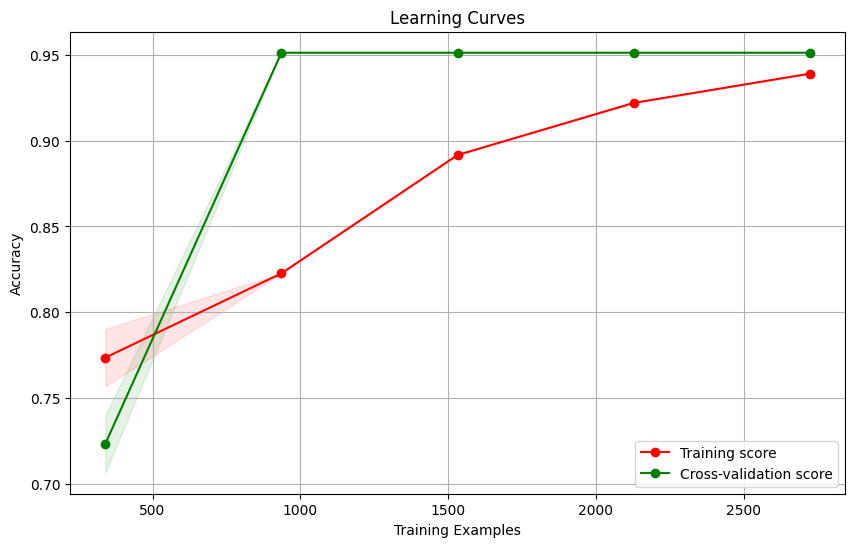

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split


data = pd.read_csv("processed_data.csv")


def plot_learning_curves(estimator, X, y, cv=3, scoring='accuracy', train_sizes=np.linspace(0.1, 0.8, 5)):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, scoring=scoring, train_sizes=train_sizes, n_jobs=-1
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="r", alpha=0.1)
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="g", alpha=0.1)
    plt.title("Learning Curves")
    plt.xlabel("Training Examples")
    plt.ylabel("Accuracy")
    plt.legend(loc="best")
    plt.grid()
    plt.show()




# Example usage
# Assuming svm_model, X, y are already defined


# Assuming 'data' is already loaded
X = data.drop(columns=['stroke'])  # Features
y = data['stroke']  # Target

# Step 2: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 3: Train the SVM model
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

# Step 4: Plot the learning curves
plot_learning_curves(svm_model, X, y, cv=3)

